In [ ]:

import pandas as pd

ANALYZED_FILE = "D:/5508data/analyzed_cleaned1.csv"   

POST_SUMMARY_FILE = "D:/5508data/post_summary.csv"
OVERALL_STATS_FILE ="D:/5508data/overall_stats.csv"
BLAME_RANK_FILE = "D:/5508data/blame_object_rank.csv"

df = pd.read_csv(ANALYZED_FILE, low_memory=False)
print(f"載入 {len(df):,} 筆評論")

# ==================== 以 sentiment_score 為主判斷情感極性 ====================
def get_sentiment_polarity(score):
    if pd.isna(score):
        return 'neu'
    if score < -0.1:
        return 'neg'
    elif score > 0.1:
        return 'pos'
    else:
        return 'neu'

df['sentiment_polarity'] = df['sentiment_score'].apply(get_sentiment_polarity)
df['has_blame_yes'] = df['has_blame'].astype(str).str.lower().str.strip().isin(['true', 'yes', '是', '1'])

print("\n=== 以 sentiment_score 判斷後的情感分布 ===")
print(df['sentiment_polarity'].value_counts())
print(f"平均 sentiment_score: {df['sentiment_score'].mean():.3f}")

# ==================== Post 層級聚合 ====================
post_group = df.groupby('post_id').agg(
    total_comments=('comment_id', 'count'),
    pos_count=('sentiment_polarity', lambda x: (x == 'pos').sum()),
    neg_count=('sentiment_polarity', lambda x: (x == 'neg').sum()),
    neu_count=('sentiment_polarity', lambda x: (x == 'neu').sum()),
    avg_sentiment_score=('sentiment_score', 'mean'),
    blame_count=('has_blame_yes', 'sum'),
).reset_index()

post_group['pos_ratio'] = post_group['pos_count'] / post_group['total_comments']
post_group['neg_ratio'] = post_group['neg_count'] / post_group['total_comments']
post_group['neu_ratio'] = post_group['neu_count'] / post_group['total_comments']
post_group['blame_ratio'] = post_group['blame_count'] / post_group['total_comments']

def get_main_blame(group):
    blames = group[group['has_blame_yes'] == True]['blame_object']
    return blames.value_counts().idxmax() if len(blames) > 0 else '無指責'

main_blame_df = df.groupby('post_id').apply(get_main_blame).reset_index(name='main_blame_object')

post_summary = post_group.merge(main_blame_df, on='post_id', how='left')
post_summary = post_summary.sort_values(by='total_comments', ascending=False).reset_index(drop=True)

post_summary.to_csv(POST_SUMMARY_FILE, index=False, encoding='utf-8-sig')

# ==================== 整體統計 ====================
total = len(df)
pos = (df['sentiment_polarity'] == 'pos').sum()
neg = (df['sentiment_polarity'] == 'neg').sum()
neu = (df['sentiment_polarity'] == 'neu').sum()

blame_count = df['has_blame_yes'].sum()
neg_with_blame = len(df[(df['sentiment_polarity'] == 'neg') & df['has_blame_yes']])

overall = pd.DataFrame([{
    'total_comments': total,
    'pos_count': int(pos),
    'pos_ratio': round(pos / total, 4) if total > 0 else 0,
    'neg_count': int(neg),
    'neg_ratio': round(neg / total, 4) if total > 0 else 0,
    'neu_count': int(neu),
    'neu_ratio': round(neu / total, 4) if total > 0 else 0,
    'avg_sentiment_score': round(df['sentiment_score'].mean(), 3),
    'total_blame_comments': int(blame_count),
    'blame_ratio': round(blame_count / total, 4) if total > 0 else 0,
    'blame_in_negative_ratio': round(neg_with_blame / neg, 4) if neg > 0 else 0,
    'most_common_blame_object': df[df['has_blame_yes']]['blame_object'].value_counts().idxmax() 
                               if df['has_blame_yes'].any() else '無'
}])

overall.to_csv(OVERALL_STATS_FILE, index=False, encoding='utf-8-sig')

blame_rank = df[df['has_blame_yes']]['blame_object'].value_counts().reset_index()
blame_rank.columns = ['blame_object', 'count']
blame_rank['percentage'] = (blame_rank['count'] / blame_count * 100).round(2) if blame_count > 0 else 0
blame_rank.to_csv(BLAME_RANK_FILE, index=False, encoding='utf-8-sig')

# ==================== 結果 ====================
print("\n" + "="*80)
print("最終整體統計結果（以 sentiment_score 為標準）")
print("="*80)
print(overall.T.to_string())

print("\n指責對象前 10 名：")
print(blame_rank.head(10))

print("\n✅ 所有結果已儲存：")
print(f"   • Post 聚合統計 → {POST_SUMMARY_FILE}")
print(f"   • 整體統計     → {OVERALL_STATS_FILE}")
print(f"   • 指責排行     → {BLAME_RANK_FILE}")

載入 78,900 筆評論

=== 以 sentiment_score 判斷後的情感分布 ===
sentiment_polarity
neg    53247
neu    23935
pos     1718
Name: count, dtype: int64
平均 sentiment_score: -0.487

最終整體統計結果（以 sentiment_score 為標準）
                                0
total_comments              78900
pos_count                    1718
pos_ratio                  0.0218
neg_count                   53247
neg_ratio                  0.6749
neu_count                   23935
neu_ratio                  0.3034
avg_sentiment_score        -0.487
total_blame_comments        45562
blame_ratio                0.5775
blame_in_negative_ratio    0.8555
most_common_blame_object  诈骗集团/骗徒

指責對象前 10 名：
  blame_object  count  percentage
0      诈骗集团/骗徒  32230       70.74
1    政府/警方/平台者   3864        8.48
2     电信/平台/银行   1962        4.31
3        受害者本人   1504        3.30
4        无明确对象   1235        2.71
5   政府/警方/监管部门   1224        2.69
6   警方/政府/监管部门   1211        2.66
7   境外势力/东南亚园区   1205        2.64
8     平台/电信/银行    264        0.58
9        平台

C:\Users\dell\AppData\Local\Temp\ipykernel_11560\3459179312.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  main_blame_df = df.groupby('post_id').apply(get_main_blame).reset_index(name='main_blame_object')


In [ ]:
post_summary = pd.read_csv("D:/5508data/post_summary.csv")

top_negative = post_summary.nlargest(10, 'neg_ratio')
print("Top 10 最負面的貼文：")
print(top_negative[['post_id', 'total_comments', 'neg_ratio', 'avg_sentiment_score', 'main_blame_object']])

Top 10 最負面的貼文：
                           post_id  total_comments  neg_ratio  \
521  LK_20251105102957639_5a40d48c              23        1.0   
535  LK_20251105102938020_2fe9d380              23        1.0   
618  LK_20251118040004381_57dd01fc              22        1.0   
631  LK_20251124040004017_ae4e9bfc              22        1.0   
644  LK_20251105103017532_1941fd79              22        1.0   
700  LK_20251105103015520_590f6f78              21        1.0   
776  LK_20251105103017377_d3b9e116              21        1.0   
800  LK_20251105102948944_ac168d8d              21        1.0   
838  LK_20251108040006788_d4777e0a              20        1.0   
853  LK_20251105103005670_d01cf9ab              20        1.0   

     avg_sentiment_score main_blame_object  
521            -0.769565           诈骗集团/骗徒  
535            -0.765217           诈骗集团/骗徒  
618            -0.793182           诈骗集团/骗徒  
631            -0.772727           诈骗集团/骗徒  
644            -0.831818           诈骗集团/骗徒  

Total 10836 posts loaded


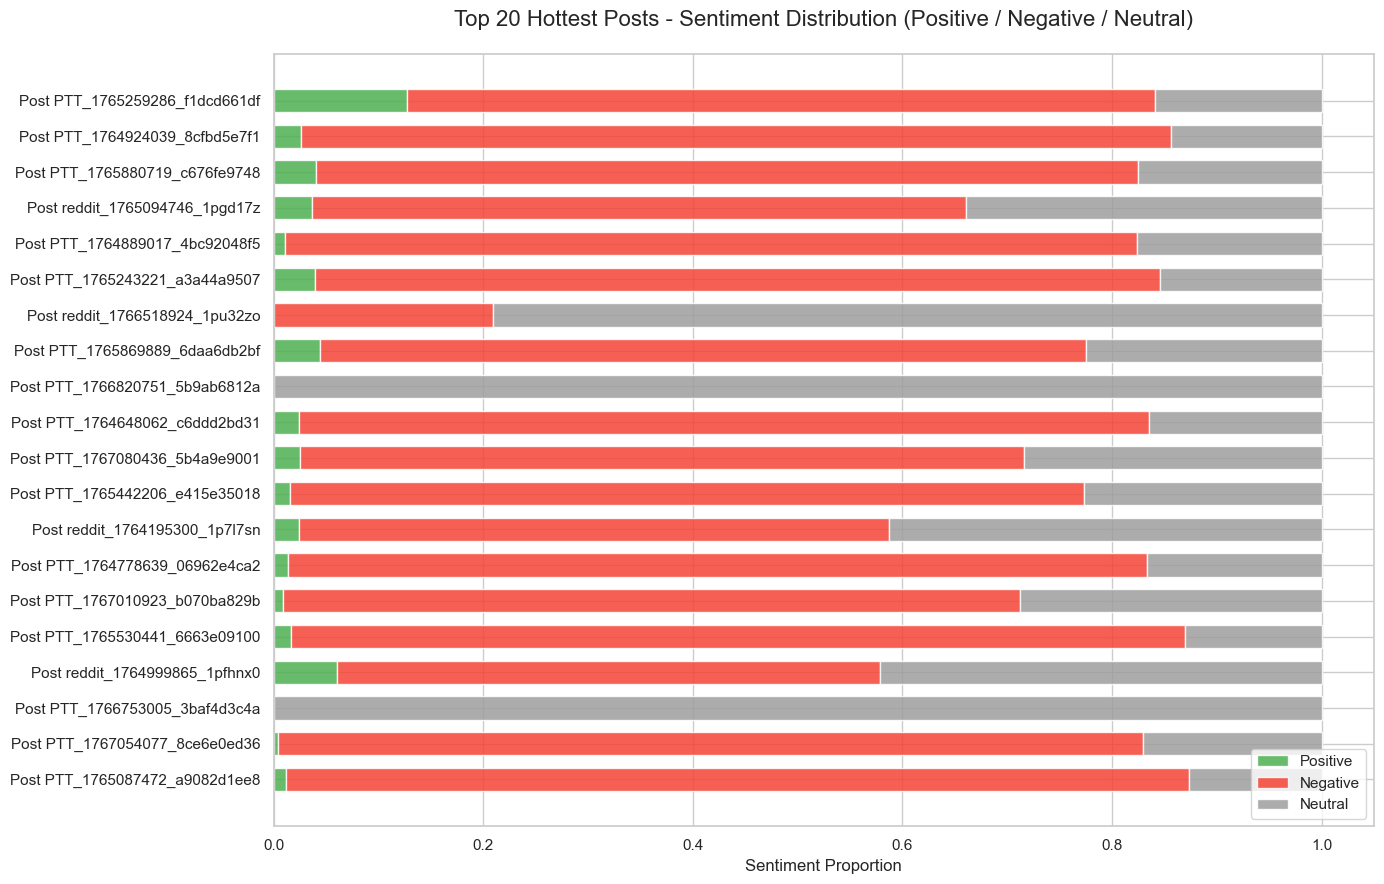

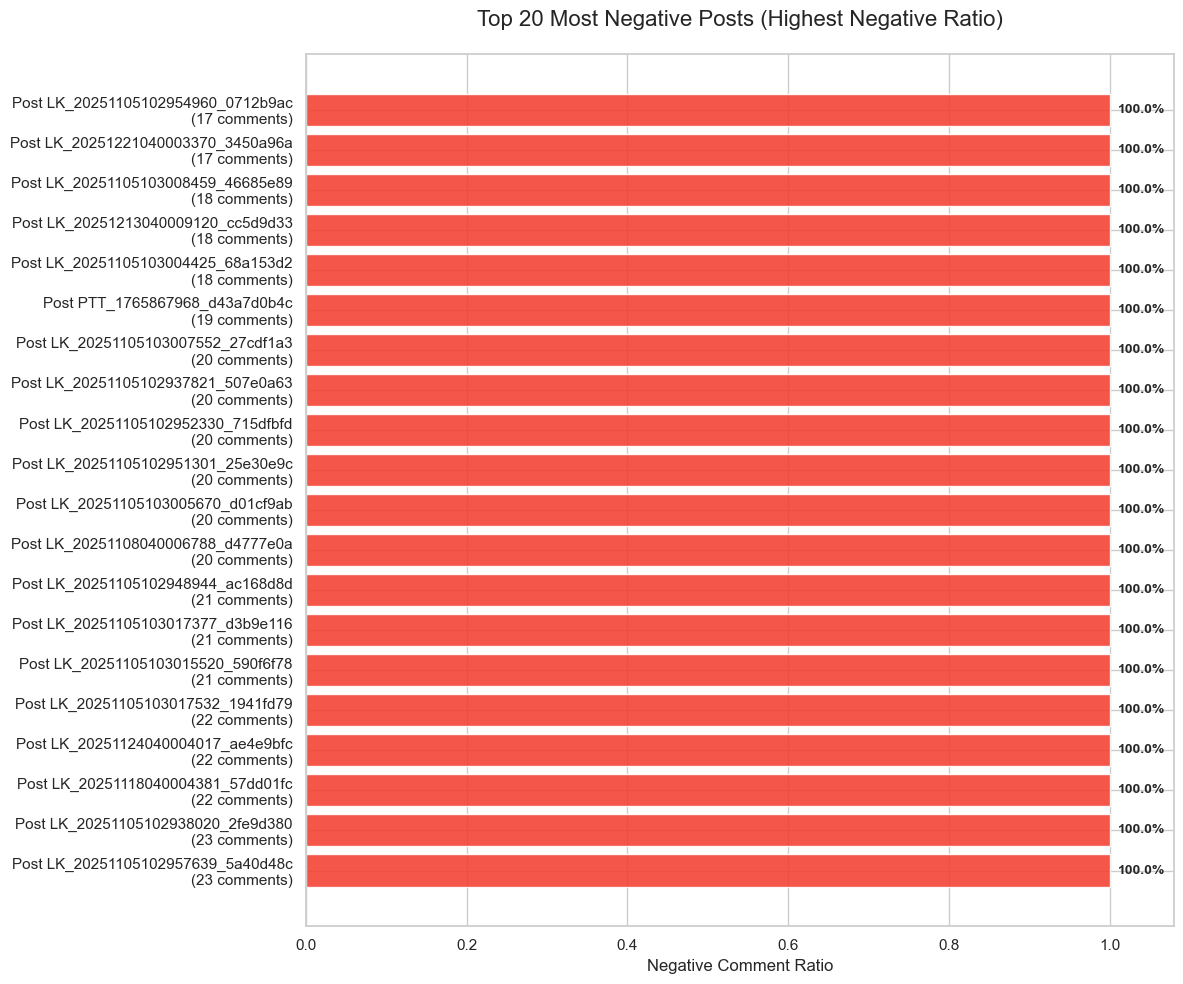

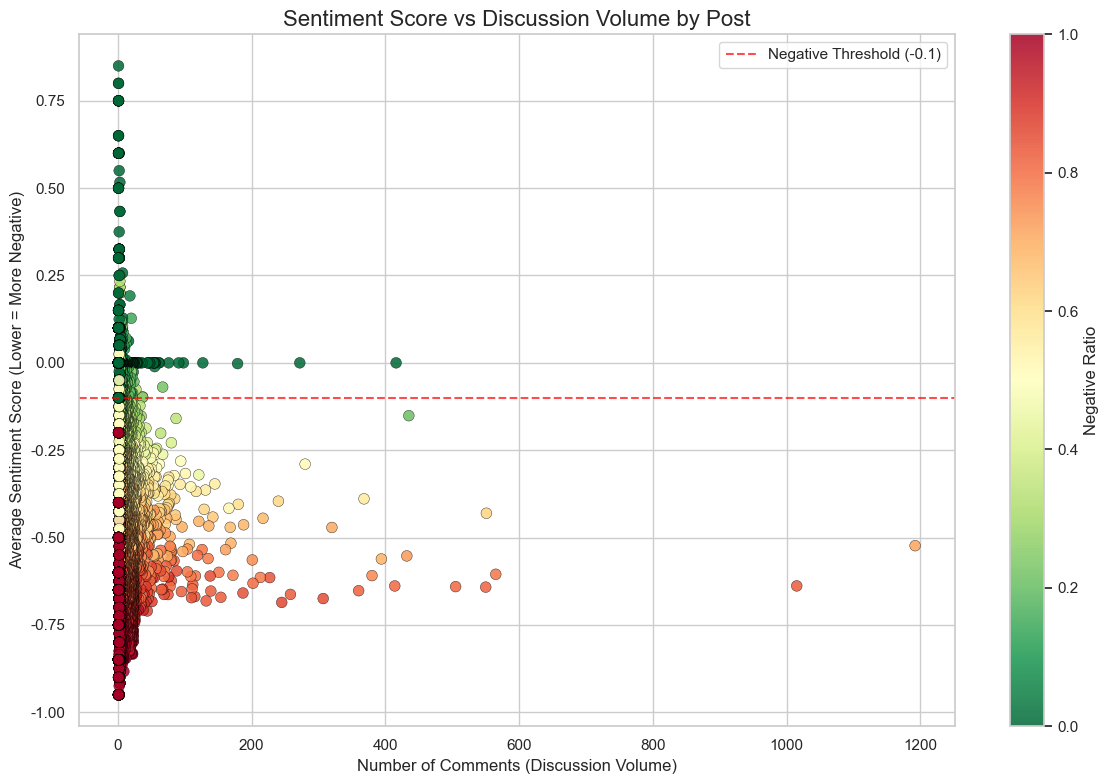

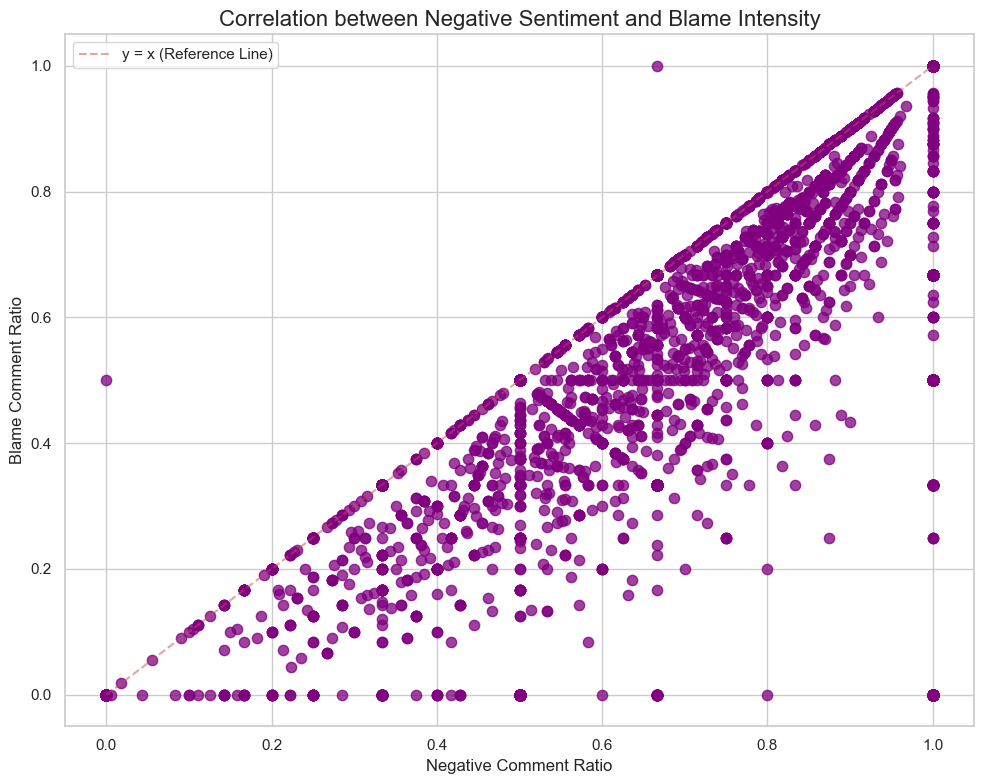

All English-labeled visualizations have been generated successfully!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

df = pd.read_csv("post_summary.csv")
print(f"Total {len(df)} posts loaded")

# ==================== 1. Top 20 Hottest Posts - Sentiment Stacked Bar ====================
top20_hot = df.nlargest(20, 'total_comments').copy()
top20_hot = top20_hot.sort_values('total_comments', ascending=True)

plt.figure(figsize=(14, 9))

x = np.arange(len(top20_hot))
width = 0.65

plt.barh(x, top20_hot['pos_ratio'], width, label='Positive', color='#4CAF50', alpha=0.85)
plt.barh(x, top20_hot['neg_ratio'], width, left=top20_hot['pos_ratio'], 
         label='Negative', color='#F44336', alpha=0.85)
plt.barh(x, top20_hot['neu_ratio'], width, 
         left=top20_hot['pos_ratio'] + top20_hot['neg_ratio'], 
         label='Neutral', color='#9E9E9E', alpha=0.85)

plt.yticks(x, [f"Post {pid}" for pid in top20_hot['post_id']])
plt.xlabel('Sentiment Proportion')
plt.title('Top 20 Hottest Posts - Sentiment Distribution (Positive / Negative / Neutral)', 
          fontsize=16, pad=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ==================== 2. Top 20 Most Negative Posts ====================
top20_neg = df.nlargest(20, 'neg_ratio').copy()

plt.figure(figsize=(12, 10))
bars = plt.barh(range(len(top20_neg)), top20_neg['neg_ratio'], color='#F44336', alpha=0.9)

plt.yticks(range(len(top20_neg)), 
           [f"Post {pid}\n({c:,} comments)" 
            for pid, c in zip(top20_neg['post_id'], top20_neg['total_comments'])])

# Add value labels on bars
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.01, i, 
             f"{top20_neg.iloc[i]['neg_ratio']:.1%}", 
             va='center', fontsize=10, fontweight='bold')

plt.xlabel('Negative Comment Ratio')
plt.title('Top 20 Most Negative Posts (Highest Negative Ratio)', fontsize=16, pad=20)
plt.xlim(0, 1.08)
plt.tight_layout()
plt.show()

# ==================== 3. Average Sentiment Score vs Comment Volume Scatter ====================
plt.figure(figsize=(12, 8))

scatter = plt.scatter(df['total_comments'], df['avg_sentiment_score'], 
                      c=df['neg_ratio'], cmap='RdYlGn_r', s=60, alpha=0.85, edgecolors='black', linewidth=0.3)

plt.colorbar(scatter, label='Negative Ratio')
plt.axhline(y=-0.1, color='red', linestyle='--', alpha=0.7, label='Negative Threshold (-0.1)')
plt.xlabel('Number of Comments (Discussion Volume)')
plt.ylabel('Average Sentiment Score (Lower = More Negative)')
plt.title('Sentiment Score vs Discussion Volume by Post', fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

# ==================== 4. Negative Ratio vs Blame Ratio Scatter ====================
plt.figure(figsize=(10, 8))
plt.scatter(df['neg_ratio'], df['blame_ratio'], alpha=0.75, s=55, color='purple')
plt.xlabel('Negative Comment Ratio')
plt.ylabel('Blame Comment Ratio')
plt.title('Correlation between Negative Sentiment and Blame Intensity', fontsize=16)
plt.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='y = x (Reference Line)')
plt.legend()
plt.tight_layout()
plt.show()

print("All English-labeled visualizations have been generated successfully!")

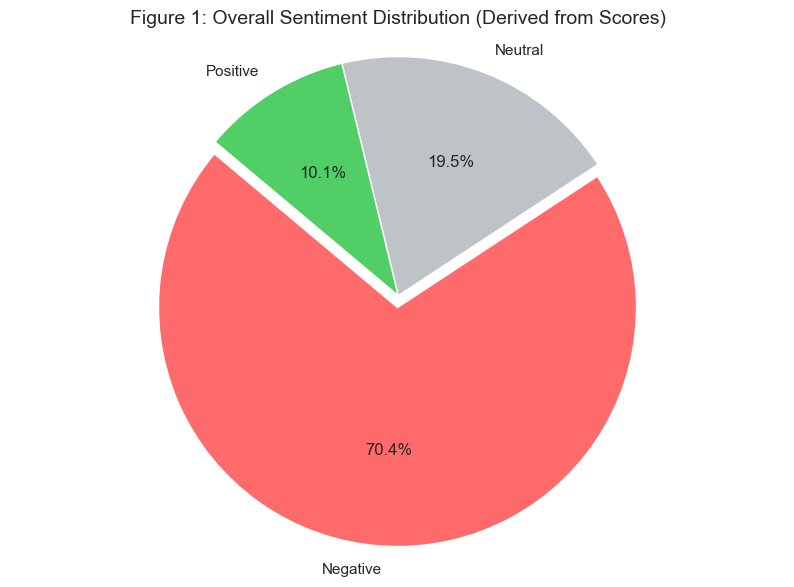

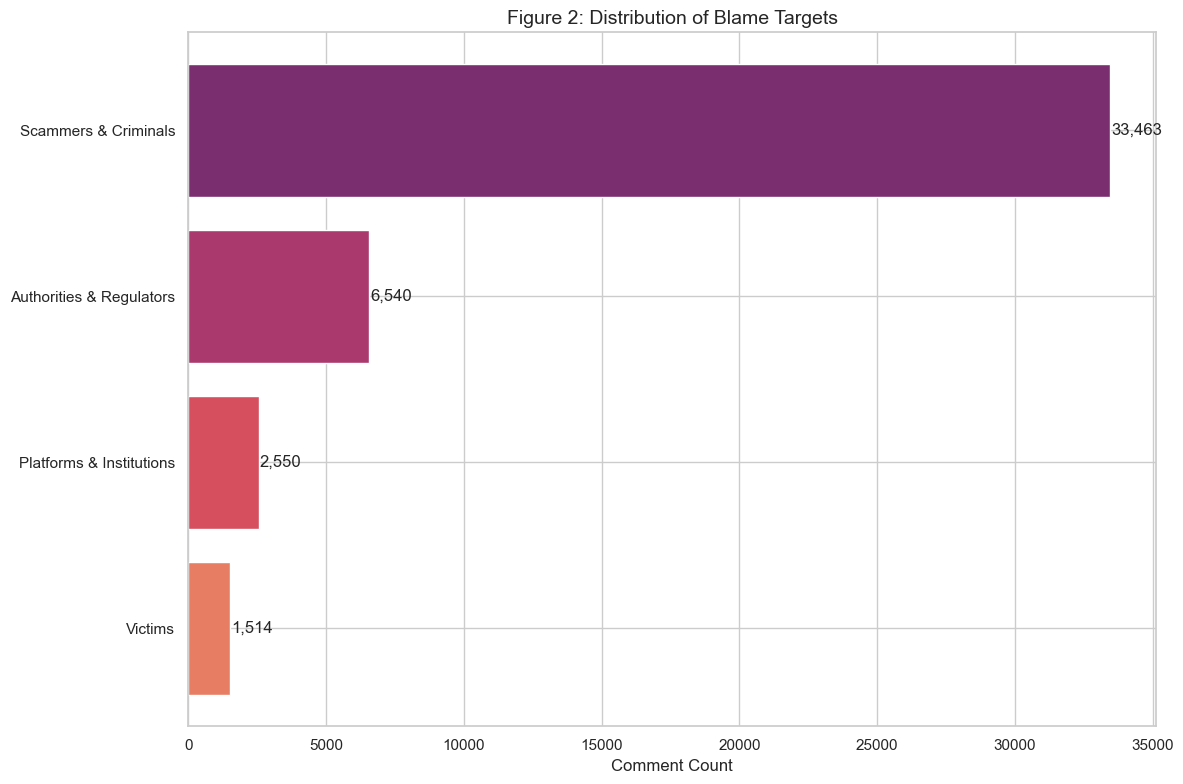

Process Complete. Table 1 generated with normalized numeric sentiments.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = 'D:/5508data/analyzed_cleaned1.csv'
df = pd.read_csv(file_path, low_memory=False)

# --- DATA CLEANING ---

if 'blame_count' not in df.columns:
    if 'has_blame' in df.columns:
        df['blame_flag'] = df['has_blame']
    elif 'blame_intensity' in df.columns:
        df['blame_flag'] = df['blame_intensity'].apply(lambda x: 1 if x > 0 else 0)
    else:
        df['blame_flag'] = 0 # Fallback

def classify_sentiment(score):
    try:
        val = float(score)
        if val <= -0.1: return 'Negative'
        elif val >= 0.1: return 'Positive'
        else: return 'Neutral'
    except:
        return 'Neutral'

df['sentiment_final'] = df['sentiment_score'].apply(classify_sentiment)

def map_blame_target(text):
    text = str(text).lower()
    if any(word in text for word in ['诈骗', '骗', 'scam', '园区', '犯罪', '被告', '骗徒']):
        return 'Scammers & Criminals'
    if any(word in text for word in ['政府', '警', '监管', '司法', '法', '官', 'gov', 'police', 'auth', '党']):
        return 'Authorities & Regulators'
    if any(word in text for word in ['平台', '银行', '电信', '商', '公司', 'app', 'bank', 'media', '校']):
        return 'Platforms & Institutions'
    if any(word in text for word in ['受害者', '被害', 'victim']):
        return 'Victims'
    return 'None / Others'

df['target_en'] = df['blame_object'].apply(map_blame_target)

# --- VISUALIZATION ---

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))
counts = df['sentiment_final'].value_counts()
colors = ['#ff6b6b', '#bdc3c7', '#51cf66'] # Red, Grey, Green

plt.pie(
    counts, labels=counts.index, autopct='%1.1f%%', 
    startangle=140, colors=colors, explode=[0.05 if x=='Negative' else 0 for x in counts.index]
)
plt.title('Figure 1: Overall Sentiment Distribution (Derived from Scores)', fontsize=14)
plt.axis('equal')
plt.show()

plt.figure(figsize=(12, 8))
blame_data = df[(df['target_en'] != 'None / Others')]
target_counts = blame_data['target_en'].value_counts().sort_values(ascending=True)

bars = plt.barh(target_counts.index, target_counts.values, color=sns.color_palette("flare", len(target_counts)))

for bar in bars:
    plt.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2, f'{int(bar.get_width()):,}', va='center')

plt.title('Figure 2: Distribution of Blame Targets', fontsize=14)
plt.xlabel('Comment Count')
plt.tight_layout()
plt.show()

table_1 = df[[
    'comment_id', 'post_id', 'sentiment_final', 'sentiment_score', 
    'blame_flag', 'target_en', 'fine_grained_emotions'
]].rename(columns={
    'sentiment_final': 'sentiment',
    'sentiment_score': 'score',
    'blame_flag': 'blame',
    'target_en': 'target',
    'fine_grained_emotions': 'emotion'
})

print("Process Complete. Table 1 generated with normalized numeric sentiments.")